### Also visualize the cell type proportions

In [1]:
import scanpy as sc 
import numpy as np
import pandas as pd
import seaborn as sns
import os
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
from libpysal.weights import KNN
from esda.moran import Moran
import cell2location
from cell2location.plt import plot_spatial

/home/william/anaconda3/envs/r-kernel/lib/python3.12/site-packages/lightning/fabric/__init__.py:40: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.


In [2]:
cell_type_proportions_dir = "cell_type_proportions/"
os.makedirs(cell_type_proportions_dir, exist_ok=True)

In [3]:
adata_list_dir = "../processed_data/"

In [4]:
adata_files = [f for f in os.listdir(adata_list_dir) if f.endswith(".h5ad") and ".ipynb_checkpoints" not in f]
adata_sample_names = [adata.replace(".h5ad", "") for adata in adata_files]

In [5]:
# most common cell types; plot these 

cell_types = ["Cardiomyocyte", "Fibroblast", "Myeloid", "Endothelial", "Pericyte"]

Visium_IZ_P10
Visium_control_P1
Visium_RZ_BZ_P3
Visium_RZ_P11
Visium_control_P8
Visium_RZ_BZ_P12
Visium_IZ_P15
Visium_GT_IZ_P13
Visium_FZ_P20
Visium_IZ_P3
Visium_control_P7
Visium_RZ_FZ_P5
Visium_FZ_P18
Visium_RZ_P6
Visium_control_P17
Visium_RZ_GT_P2
Visium_RZ_BZ_P2
Visium_IZ_BZ_P2
Visium_RZ_P3
Visium_GT_IZ_P9
Visium_FZ_GT_P19


/home/william/anaconda3/envs/r-kernel/lib/python3.12/site-packages/cell2location/plt/plot_spatial.py:212: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure()


Visium_FZ_P14
Visium_GT_IZ_P9_rep2
Visium_IZ_P16
Visium_FZ_GT_P4
Visium_RZ_P9
Visium_GT_IZ_P15


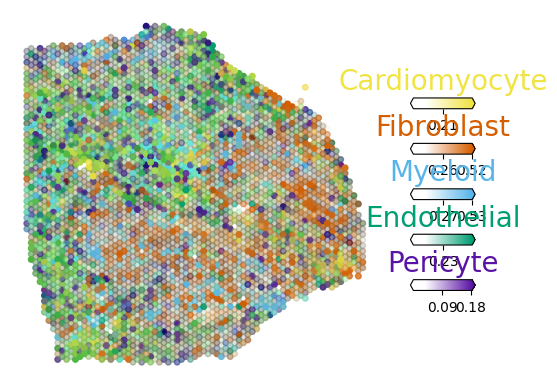

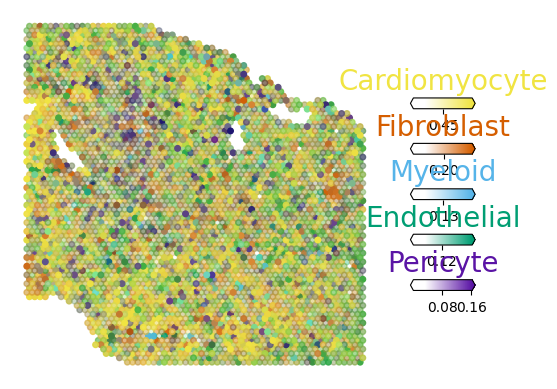

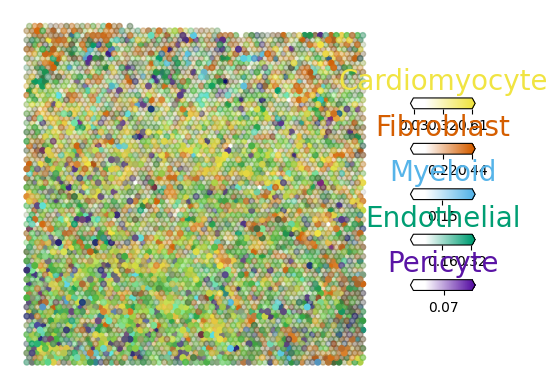

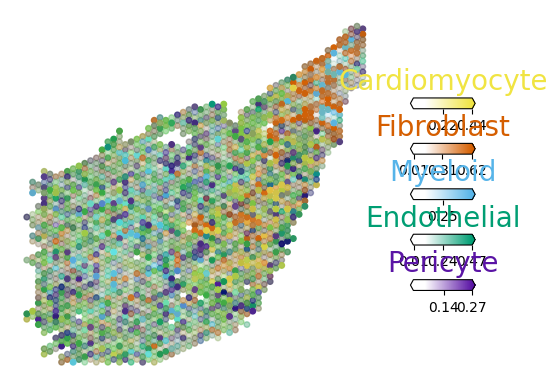

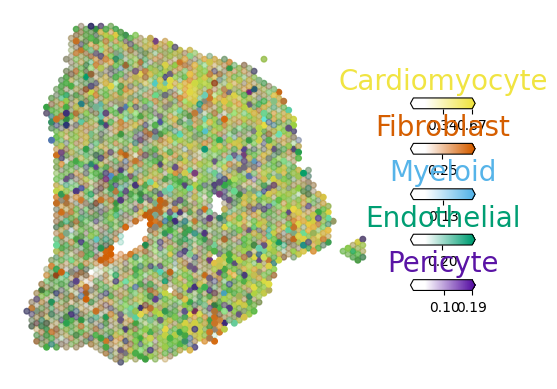

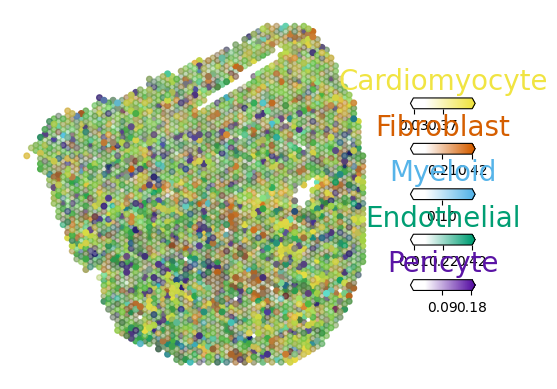

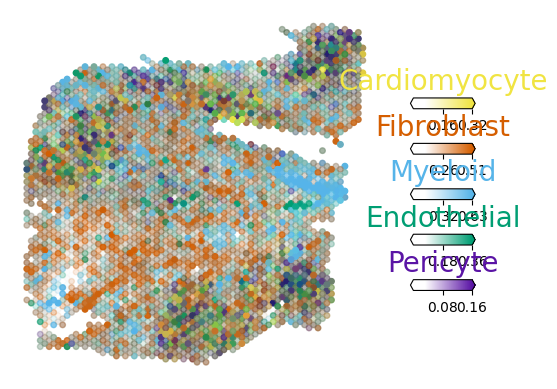

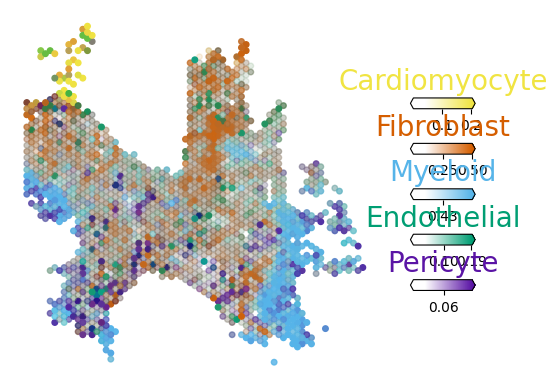

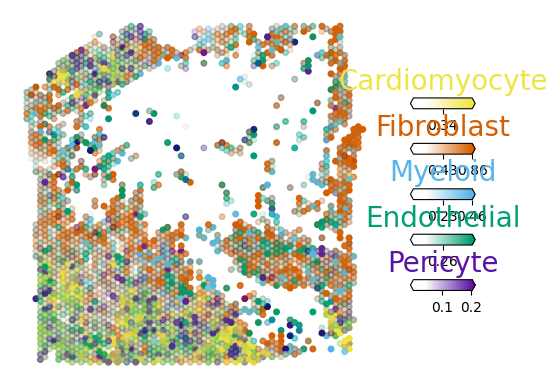

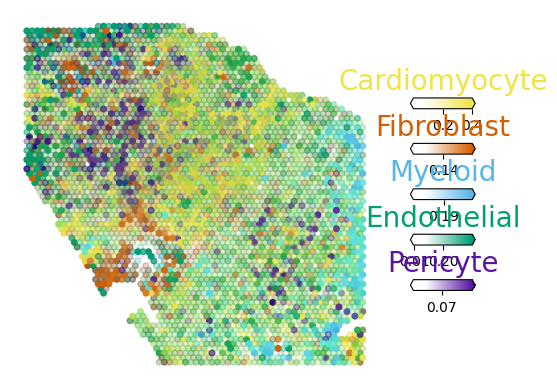

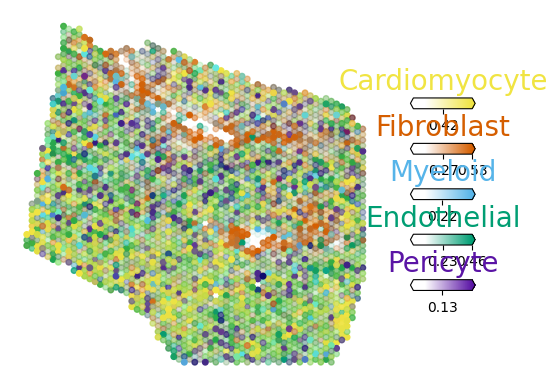

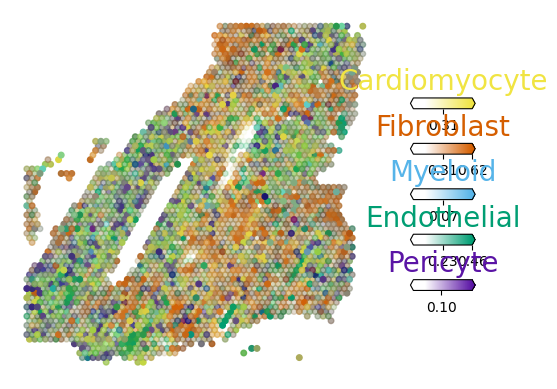

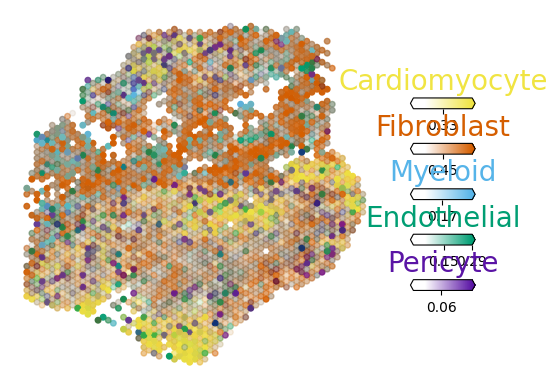

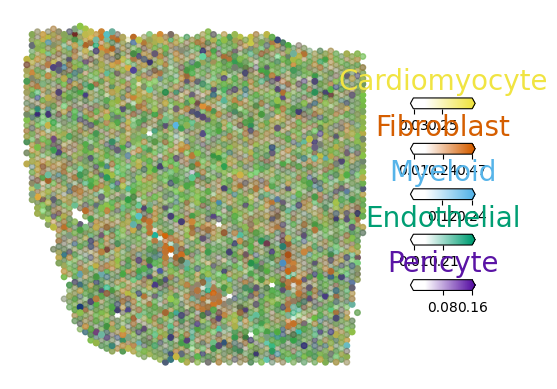

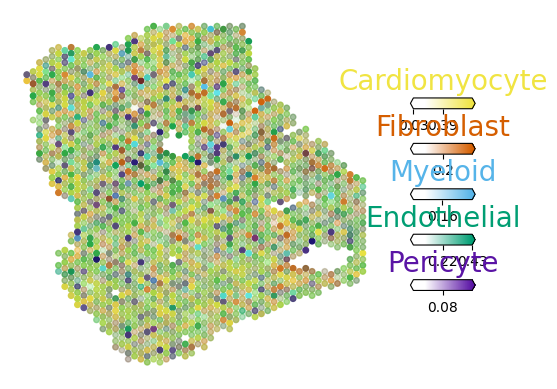

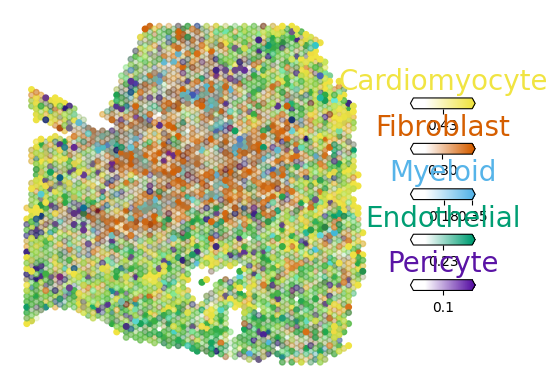

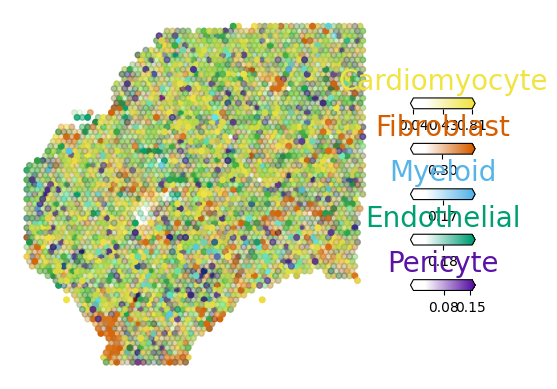

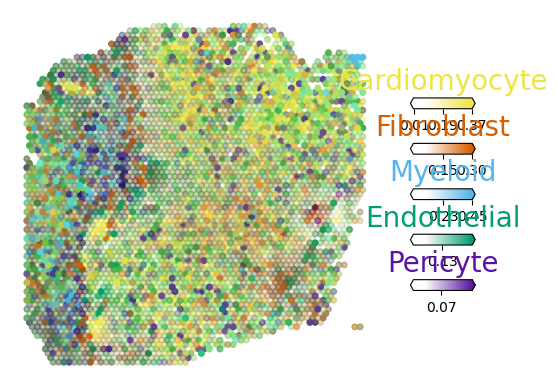

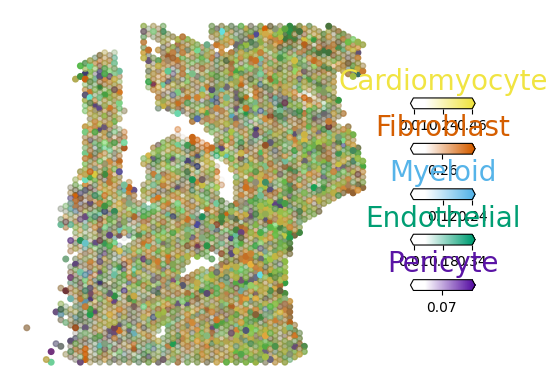

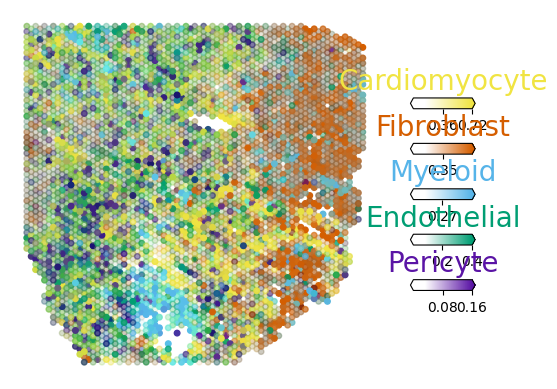

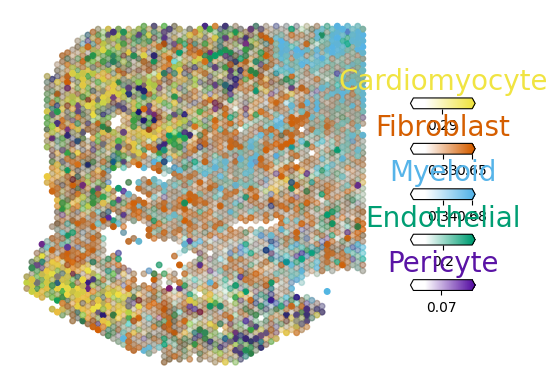

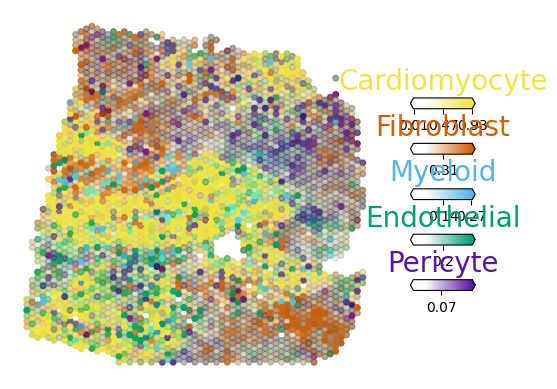

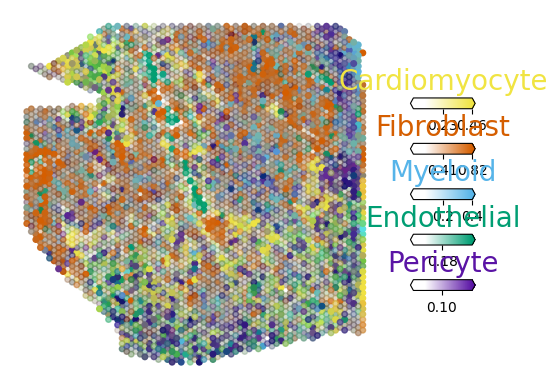

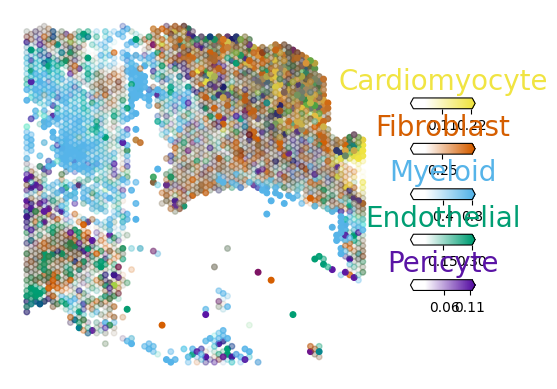

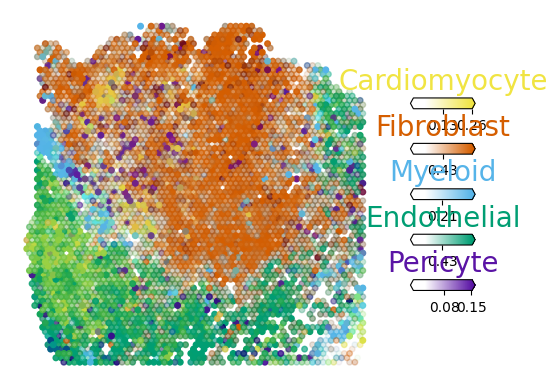

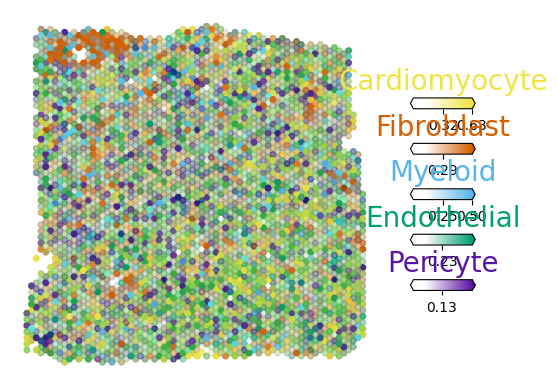

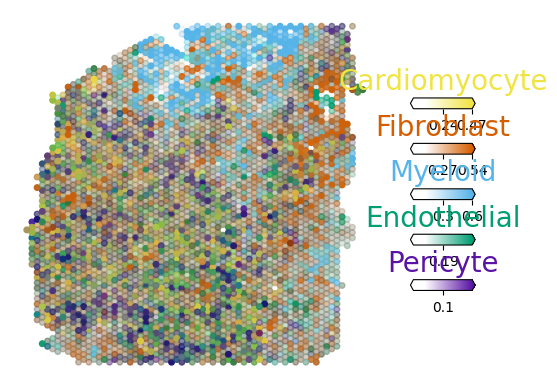

In [6]:
for adata_sample, adata_file in zip(adata_sample_names, adata_files):
    print(adata_sample, flush=True)
    adata = sc.read_h5ad(adata_list_dir + adata_file)

    # format for cell2location
    adata.obsm['spatial'] = adata.obsm['X_spatial']

    # plot with cell2location and save it
    with plt.rc_context():
        cell2location.plt.plot_spatial(adata, color = cell_types, labels = cell_types, img_key='hires', show_img=False,
                               colorbar_position='right', colorbar_tick_size=10, adjust_text=True)
        plt.savefig(cell_type_proportions_dir + adata_sample + ".pdf")

### Version using scanpy

In [7]:
#sc.pl.spatial(adata, color=cell_types, img_key="hires", spot_size=0.0175, size=1.3, alpha_img=0.6, edges_width=0.01,
#    vmin=0, vmax=1, show=False, ncols = 5)